# Notebook 5 - Feature Engineering & Model Training## Cookie Cats A/B Testing**Phase:** CRISP-DM Phase 3 & 4 - Data Preparation & Modelling> **Navigation:** <- `04_eda_visualizations.ipynb` | Next -> `06_evaluation_and_ab_testing.ipynb`---

## Step 0 - Environment Setup

In [ ]:
import sys, os, warningswarnings.filterwarnings('ignore')sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_style('whitegrid')plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})os.makedirs('../reports/figures', exist_ok=True)print("Environment ready.")

---## Step 1 - Load Augmented Dataset

In [ ]:
df = pd.read_csv('../data/processed/cookie_cats_augmented.csv')print(f"Augmented dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")

---## Step 2 - Feature Engineering

In [11]:
from processing import engineer_features

df_feat = engineer_features(df_augmented)
print(f"Features added. Shape: {df_feat.shape}")
df_feat.head()

Engineered features added. New shape: (90189, 15)
Features added. Shape: (90189, 15)


,userid,version,sum_gamerounds,retention_1,retention_7,industry_d1_retention,industry_d7_retention,industry_d30_retention,industry_avg_session_min,genre_market_share_pct,retention_vs_industry,gamerounds_bin,high_engagement,retention_1_x_rounds,rounds_per_day_proxy
0,116,gate_30,3,0,0,0.45,0.22,0.09,5.8,15.0,-0.22,casual,0,0,0.428571
1,337,gate_30,38,1,0,0.45,0.22,0.09,5.8,15.0,-0.22,moderate,0,38,5.428571
2,377,gate_40,165,1,0,0.45,0.22,0.09,5.8,15.0,-0.22,active,1,165,23.571429
3,483,gate_40,1,0,0,0.45,0.22,0.09,5.8,15.0,-0.22,inactive,0,0,0.142857
4,488,gate_40,179,1,1,0.45,0.22,0.09,5.8,15.0,0.78,active,1,179,25.571429


---## Step 3 - Quick EDA on Engineered Features

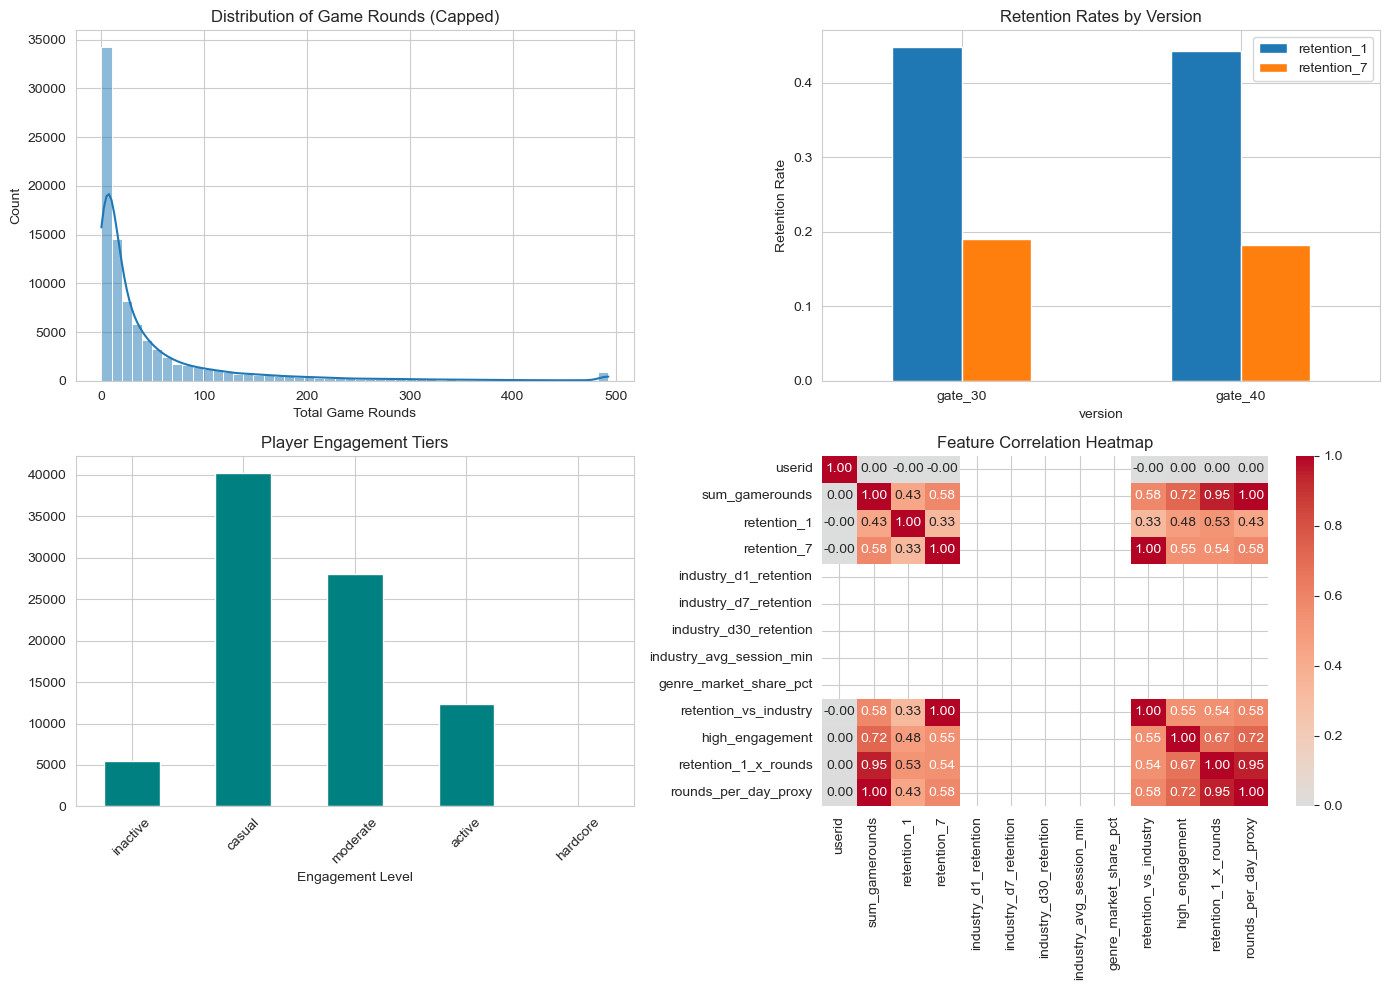


✓ Figure saved to reports/figures/eda_overview.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Game rounds distribution
sns.histplot(df_feat['sum_gamerounds'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Game Rounds (Capped)')
axes[0, 0].set_xlabel('Total Game Rounds')

# Retention by version
retention_by_version = df_feat.groupby('version')[['retention_1', 'retention_7']].mean()
retention_by_version.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Retention Rates by Version')
axes[0, 1].set_ylabel('Retention Rate')
axes[0, 1].tick_params(axis='x', rotation=0)

# Engagement tier distribution
df_feat['gamerounds_bin'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Player Engagement Tiers')
axes[1, 0].set_xlabel('Engagement Level')
axes[1, 0].tick_params(axis='x', rotation=45)

# Correlation heatmap
numeric_cols = df_feat.select_dtypes(include='number').columns
corr = df_feat[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved to reports/figures/eda_overview.png")

---## Step 4 - Train / Test Split

In [13]:
from processing import prepare_modeling_data

X_train, X_test, y_train, y_test = prepare_modeling_data(df_feat)

Train: 72,151  |  Test: 18,038
Positive-class rate (train): 0.1861


---## Step 5 - Model Training (sklearn Pipeline)Three models via `imblearn.Pipeline` with SMOTE:- **Logistic Regression** - baseline- **Random Forest** - ensemble- **XGBoost** - gradient boosting

In [14]:
from modeling import train_models

trained_models = train_models(X_train, y_train)
print(f"\n✓ {len(trained_models)} models trained")

  Training Logistic Regression …
  Training Random Forest …
  Training XGBoost …
  Training Gradient Boosting …

✓ 4 models trained


---## Step 6 - Hyperparameter TuningGridSearchCV with 5-fold stratified CV.

In [15]:
from modeling import tune_hyperparameters

tuned_xgb = tune_hyperparameters(X_train, y_train, model_name='XGBoost')
tuned_rf = tune_hyperparameters(X_train, y_train, model_name='Random Forest')

Tuning XGBoost (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
  Best CV roc_auc: 0.8892
Tuning Random Forest (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best CV roc_auc: 0.8889


---## Summary| Step | Action | Output ||------|--------|--------|| Features | `engineer_features()` | Interaction terms, bins || Split | `prepare_modeling_data()` | 80/20 stratified || Train | `train_models()` | LR, RF, XGBoost || Tune | `tune_hyperparameters()` | Best params via GridSearchCV |-> Next: `06_evaluation_and_ab_testing.ipynb`